# Lab 3

This lab covers information from the third week of class - lectures 6, 7, and 8:
- Neighbors and distance metrics
- k-Nearest Neighbor
- Data splitting & Cross-validation

### Learning Objectives
- Understand the power and limitations of k-NN and various distance metrics on toy and real-world datasets
- Optimize hyperparameters (k in k-NN) by assessing their effect on cross-validation error
- Apply t-SNE to visualize a real scRNA-seq dataset
- Discuss class imbalance in classification problems

## Section 1 - Bonus: Proof of Non-negativity

A similarity metric, $D$, must have three properties:
- Identity of indiscernibles
  - $D(\vec x, \vec y) = 0 \iff \vec x = \vec y$
- Symmetry
  - $D(\vec x, \vec y) = D(\vec y, \vec x)$
- Triangle inequality
  - $D(\vec x, \vec z) \leq D(\vec x, \vec y) + D(\vec y, \vec z)$


These 3 facts directly lead to a fourth property, which is that similarity metrics are always non-negative! In this lab we will create the proof that non-negative follows from these three properties.

## Section 2: k-NN Visualizations with Toy Data
*You should be able to work through this section anytime after the k-NN lecture.*

First we will compare some different distance metrics and different values of $k$ in a simple k-nearest neighbor model using a toy dataset.

The decision boundaries show what the classification of a test datapoint in that space would be - similar to "Voronoi diagrams."

### Cosine Similarity Example

Cosine similarity measures the "directionality" of the data. As an extra example, the code block below simulates data that would be easily separable using a cosine similarity metric, but not euclidean distance. In this particular case, the classes are also entirely distinct in "y" but not in "x" - while the "x" value looks meaningful on the plot, it has no effect on the class labels.

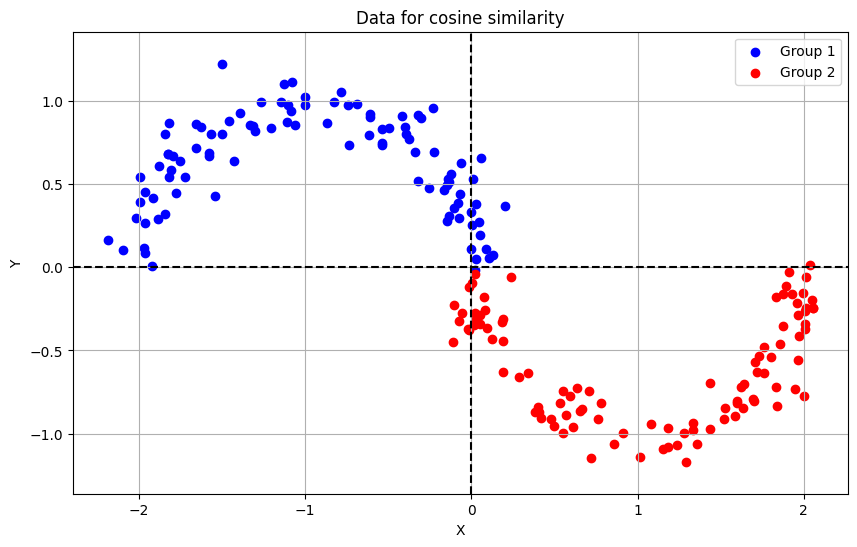

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_semicircular_data(center, num_points, radius, angle_range, jitter_scale=0.1):
    angles = np.random.uniform(angle_range[0], angle_range[1], num_points)
    x = center[0] + radius * np.cos(angles)
    y = center[1] + radius * np.sin(angles)

    # Add jitter
    x_jitter = np.random.normal(0, jitter_scale, num_points)
    y_jitter = np.random.normal(0, jitter_scale, num_points)
    x += x_jitter
    y += y_jitter

    return np.column_stack((x, y))

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
num_points_per_group = 100
radius = 1
jitter_scale = 0.1

# Generate data for the first group (centered on (-1,0), upper semicircle)
group1_center = (-1, 0)
group1_data = generate_semicircular_data(group1_center, num_points_per_group, radius, (0, np.pi), jitter_scale)

# Generate data for the second group (centered on (1,0), lower semicircle)
group2_center = (1, 0)
group2_data = generate_semicircular_data(group2_center, num_points_per_group, radius, (np.pi, 2*np.pi), jitter_scale)

# Combine the data
all_data = np.vstack((group1_data, group2_data))

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(group1_data[:, 0], group1_data[:, 1], c='blue', label='Group 1')
plt.scatter(group2_data[:, 0], group2_data[:, 1], c='red', label='Group 2')
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data for cosine similarity')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

### 2.2: Splits & Cross-validation - choosing the best value of k

The above exercise used ALL the data as training data, which means the $k=1$ case has 100% accuracy in classifying the training data! However, we can see that the decision boundaries drawn by that model are noisy and do not reflect how the data were simulated (ground truth). While looking at the data and decision boundaries across a couple values of k above probably gave you a good sense of what values of k might be reasonable, we can carry out a more systematic and quantitative examination.

We'd like to use data splitting and cross-validation to accomplish 2 things in this section:
1. Get a sense of how accurate our model is on new (test) data
2. Compare those accuracies across different values of k to quantitatively choose the best value of k.

❓2.2.1 Some useful documentation:
- [`scikitlearn` k-fold splits](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) to split your data
- [kNN in `scikitlearn`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [`cross_val_score` function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to estimate accuracy across folds
- [`argmax` function](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) to help find the best value of k.


## Section 3: tSNE! (PBMCs)

### A Somewhat Longwinded Description of the Dataset
This dataset is a single-cell RNA-sequencing (scRNA-seq) dataset of ~3,000 Peripheral blood mononuclear cells (PBMCs). "PBMC" is an umbrella term that contains several distinct celltypes including lymphocytes (T cells and B cells of various types), monocytes, and granulocytes (neutrophils, basophils, etc.).

**Why do we care about this kind of data?** scRNA-seq is used to measure the gene expression of individual cells by directly capturing RNA transcripts within those cells. While there are many applications of scRNA-seq, most of them explore identifying different cell types or sub-types within the data. Cells within a celltype can be thought of as "neighbors" or "similar objects." Broadly, different celltypes have diverse functions and react differently to stimuli such as drugs or disease. Sometimes there are particular "marker genes" that differ in expression between cell types of interest that "mark" the different populations of cells. (We will use some of these later.)

**What does this data look like?** scRNA-seq measures gene expression of individual cells. Usually, scRNA-seq data is presented as a sparse counts matrix of genes x cells: every row represents a different gene, and every column represents a different cell. Each entry in the matrix is a count of transcripts of the given gene (row) for the particular given cell (column).
> This is backwards from most data science! scRNA-seq data stores *observations* (cells) as *columns* and *features* (genes) as *rows*.

The data are said to be "sparse" because of the high number of 0s in the counts matrix. These 0s occur because
> 1) in a heterogeneous sample of cells, not every gene measured across a dataset is expressed in every (or even most) cell(s)

> 2) scRNA-seq does not observe every single transcript in a given cell, but instead can be thought to randomly sample *some* of the transcripts from every cell. Especially at low sequencing depths, not every transcript is detected in the data output.

Initially this dataset had 13714 features (genes) and 2700 observations (cells). That's quite large, though that is not even the full set of genes or transcripts or features we could measure across the human genome. As a final technical note, single-cell capture methods have expanded to include protein and chromatin accessibility information, adding even more possible features and making single-cell data increasingly high-dimensional.

For the purposes of this class, we've subset the data to only *some* of the genes and *most* of the cells. For more information on this dataset and scRNA-seq preprocessing, you can read some of the fabulous [Seurat tutorial](https://satijalab.org/seurat/articles/pbmc3k_tutorial.html) on this dataset.

### 3.1: Load the Data and Manipulate

❓3.1.1 *As a check for you: The column names look like incomprehensible strings of DNA letters with a `-1` after them. Those strings of DNA letters are the DNA cell barcodes from the sequencing data, and the `-1` tag refers to the lane/library (batch) these cells came from. Since every cell has a different DNA barcode, the barcodes are the most convenient choice of column name.*

❓3.1.2 As mentioned in the description above, observations are columns in this dataset instead of rows.

### 3.2: Make a t-SNE Plot

❓3.2.1 *Documentation for TSNE is [here](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).*

### 3.3: Color the t-SNE Plot by Marker Gene Expressions

These cells appear to be in 3 similar "groups" or cell types on our plot. These are the subtypes of PBMCs! We can check to see which cluster is which by visualizing the expression of what are called "marker genes," that help identify these cell-types.

❓3.3.1  *Just like in last lab, you have to do the same thing several times! It may be worth writing a function or loop to generate these plots as subplots in a figure.*

❓3.3.2 *PPBP is "pro-platelet basic protein" and marks platelets, which are non-nucleated celltype found in low density in the PBMC dataset.*

✅ Answer:

### 3.4: Color tSNE by external labels
❓3.4.1 *Using seaborn to plot will help you get the cells labelled clearly easily, without too much data manipulation.*

As a final note from looking at these plots, be aware that the tSNE plot is just a 2-dimensional representation of very complex data. It lets us look at the data, but as you can see from plotting the expression level of just a few (relevant!) genes and some external labels, it's difficult to understand the complex neighbor relationships that draw cells together.

## ⭐ Bonus - Section 4: A Return to kNN - PBMCs

Now we're going to try using k-NN to group the PBMC data and compare the classifications kNN produces to the t-SNE embedding.

⭐4.1 *Because the t-SNE embeddings have to be made on the full dataset, the first part of the code does the test-train splits for you, then recombines them into a single pandas dataframe for plotting purposes.*
> Useful documentation:
- [`train_test_split` function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)